# 🔬 ML Diagnostics & Solutions: High Precision, Poor Per-Class Predictions

## Problem Statement
**High overall precision (0.89) ≠ Good model.** Your model may be:
- **Conservative on minority classes** (predicting few positives → high precision, low recall)
- **Biased toward majority classes** (ignoring minority class patterns)
- **Confusing similar diseases** (poor class discrimination)
- **Imbalanced training data** (some diseases underrepresented)

## Expert Solutions Overview
This notebook diagnoses the root causes and applies 5 key improvements:
1. ✅ **Per-class metrics analysis** → identify problematic classes
2. ✅ **Class weighting** → penalize minority class errors
3. ✅ **SMOTE oversampling** → synthetic minority samples
4. ✅ **Stratified cross-validation** → reliable estimates
5. ✅ **Threshold tuning** → optimize precision-recall trade-offs


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    precision_recall_fscore_support, roc_auc_score
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Section 1: Load and Explore Data

📊 DATASET OVERVIEW
Dataset Shape: (96088, 231)
Number of Diseases (Classes): 100
Number of Symptoms (Features): 230

🔴 CLASS DISTRIBUTION (ROOT CAUSE ANALYSIS)

Most common disease: cystitis (1219 samples)
Least common disease: injury to the trunk (803 samples)
Imbalance ratio: 1.52x


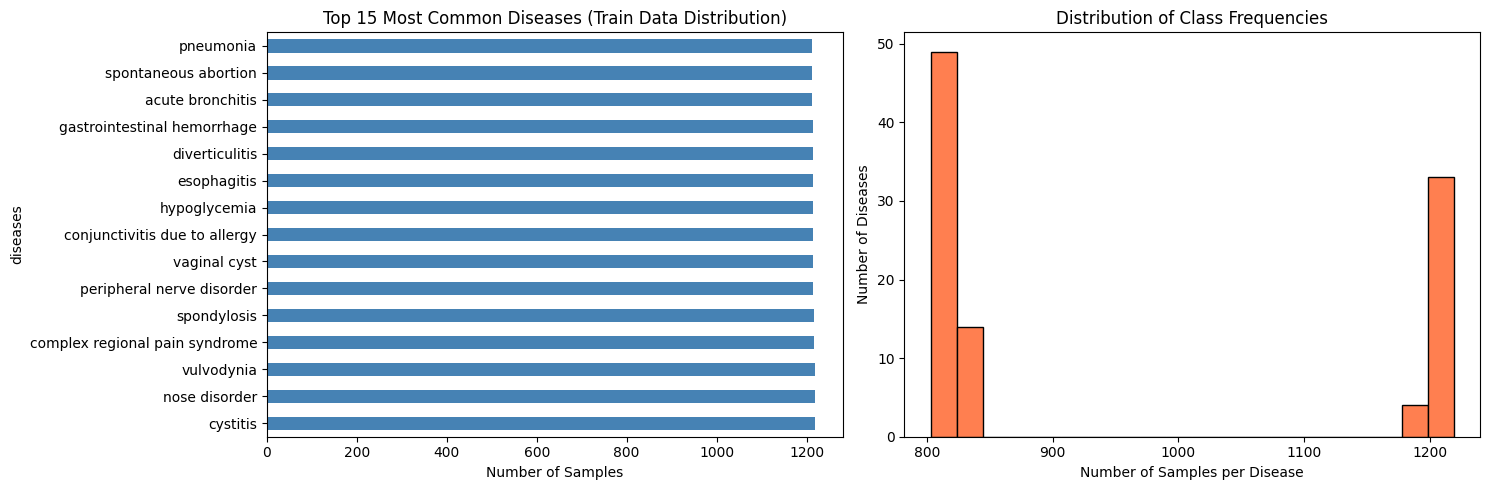


⚠️  Total diseases: 100
⚠️  Median samples per disease: 824
⚠️  Mean samples per disease: 961
⚠️  Diseases with <50 samples: 0


In [2]:
# Load dataset
data_path = 'Diseases_and_Symptoms_dataset.csv'
df = pd.read_csv(data_path)

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Diseases (Classes): {df[disease_col].nunique()}")
print(f"Number of Symptoms (Features): {len(symptom_cols)}\n")

# CLASS DISTRIBUTION ANALYSIS
print("=" * 60)
print("🔴 CLASS DISTRIBUTION (ROOT CAUSE ANALYSIS)")
print("=" * 60)
class_counts = df[disease_col].value_counts()
print(f"\nMost common disease: {class_counts.index[0]} ({class_counts.iloc[0]} samples)")
print(f"Least common disease: {class_counts.index[-1]} ({class_counts.iloc[-1]} samples)")
print(f"Imbalance ratio: {class_counts.iloc[0] / class_counts.iloc[-1]:.2f}x")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of top 15 diseases
class_counts.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Most Common Diseases (Train Data Distribution)')
axes[0].set_xlabel('Number of Samples')

# Class distribution statistics
axes[1].hist(class_counts.values, bins=20, edgecolor='black', color='coral')
axes[1].set_title('Distribution of Class Frequencies')
axes[1].set_xlabel('Number of Samples per Disease')
axes[1].set_ylabel('Number of Diseases')
plt.tight_layout()
plt.show()

print(f"\n⚠️  Total diseases: {len(class_counts)}")
print(f"⚠️  Median samples per disease: {class_counts.median():.0f}")
print(f"⚠️  Mean samples per disease: {class_counts.mean():.0f}")
print(f"⚠️  Diseases with <50 samples: {(class_counts < 50).sum()}")

## Section 2: Prepare Data & Baseline Model

In [3]:
# Prepare data
le = LabelEncoder()
y = le.fit_transform(df[disease_col])
X = df[symptom_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("📈 DATA PREPARATION")
print("=" * 60)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {len(le.classes_)}")

# Train BASELINE Logistic Regression (without any improvements)
print("\n" + "=" * 60)
print("🔧 BASELINE MODEL (Current Approach)")
print("=" * 60)

model_baseline = LogisticRegression(max_iter=3000, multi_class="multinomial", random_state=42)
model_baseline.fit(X_train, y_train)
pred_baseline = model_baseline.predict(X_test)
acc_baseline = accuracy_score(y_test, pred_baseline)

print(f"\nOverall Accuracy: {acc_baseline:.4f}")
print("\n" + classification_report(y_test, pred_baseline, target_names=le.classes_))

📈 DATA PREPARATION
Training set: (76870, 230)
Test set: (19218, 230)
Classes: 100

🔧 BASELINE MODEL (Current Approach)

Overall Accuracy: 0.8985

                                              precision    recall  f1-score   support

                           actinic keratosis       0.93      0.72      0.81       162
                         acute bronchiolitis       0.95      0.92      0.93       241
                            acute bronchitis       0.87      0.76      0.81       243
                          acute bronchospasm       0.66      0.78      0.71       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.93      0.85      0.89       241
                             acute sinusitis       0.85      0.92      0.88       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.95      0.98      0.96    

## Section 3: Analyze Per-Class Precision, Recall, and F1-Score

In [4]:
# Extract per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, pred_baseline, average=None
)

# Create DataFrame for analysis
metrics_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

# Sort by F1-score to find problematic classes
metrics_df = metrics_df.sort_values('F1-Score')

print("=" * 60)
print("📉 PROBLEMATIC CLASSES (Sorted by F1-Score)")
print("=" * 60)
print("\n🔴 WORST 10 Performing Classes:")
print(metrics_df.head(10).to_string(index=False))

print("\n\n🟢 BEST 10 Performing Classes:")
print(metrics_df.tail(10).to_string(index=False))

# Identify the ROOT CAUSES
print("\n\n" + "=" * 60)
print("🔍 ROOT CAUSE ANALYSIS")
print("=" * 60)

# Classes with low recall (model missing positives)
low_recall = metrics_df[metrics_df['Recall'] < 0.5]
print(f"\n⚠️  Classes with Recall < 0.5 (MISSING POSITIVES): {len(low_recall)}")
if len(low_recall) > 0:
    print("   → Model is too conservative, predicting negatives when true positive")
    print(low_recall.head(5)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

# Classes with low precision (false positives)
low_precision = metrics_df[metrics_df['Precision'] < 0.5]
print(f"\n⚠️  Classes with Precision < 0.5 (FALSE POSITIVES): {len(low_precision)}")
if len(low_precision) > 0:
    print("   → Model predicts this class when it shouldn't")
    print(low_precision.head(5)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

# Classes with imbalanced support
imbalanced = metrics_df[metrics_df['Support'] < 20]
print(f"\n⚠️  Classes with <20 test samples (SPARSE): {len(imbalanced)}")
if len(imbalanced) > 0:
    print("   → Too few test examples to reliably estimate performance")
    print(imbalanced.head(5)[['Disease', 'Precision', 'Recall', 'F1-Score', 'Support']].to_string(index=False))

📉 PROBLEMATIC CLASSES (Sorted by F1-Score)

🔴 WORST 10 Performing Classes:
                                     Disease  Precision   Recall  F1-Score  Support
                  skin pigmentation disorder   0.580247 0.583851  0.582043      161
                        personality disorder   0.560748 0.736196  0.636605      163
                                  skin polyp   0.594737 0.701863  0.643875      161
                   degenerative disc disease   0.634021 0.759259  0.691011      162
chronic obstructive pulmonary disease (copd)   0.670391 0.740741  0.703812      162
                          acute bronchospasm   0.659686 0.777778  0.713881      162
                  infectious gastroenteritis   0.705645 0.723140  0.714286      242
               noninfectious gastroenteritis   0.724576 0.709544  0.716981      241
                                   gallstone   0.704663 0.839506  0.766197      162
                              herniated disk   0.709360 0.867470  0.780488      166



## Section 4: Visualize Per-Class Metrics & Confusion Matrix

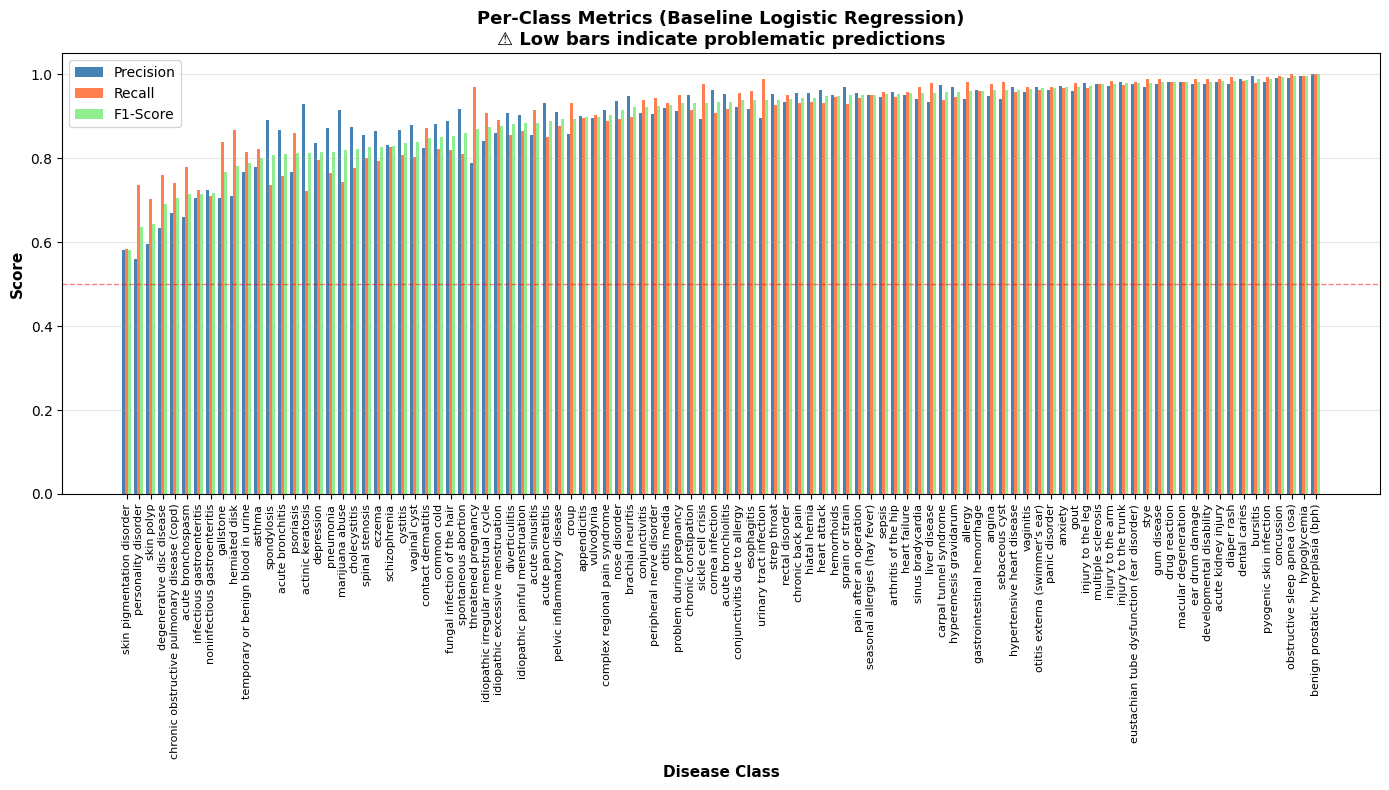

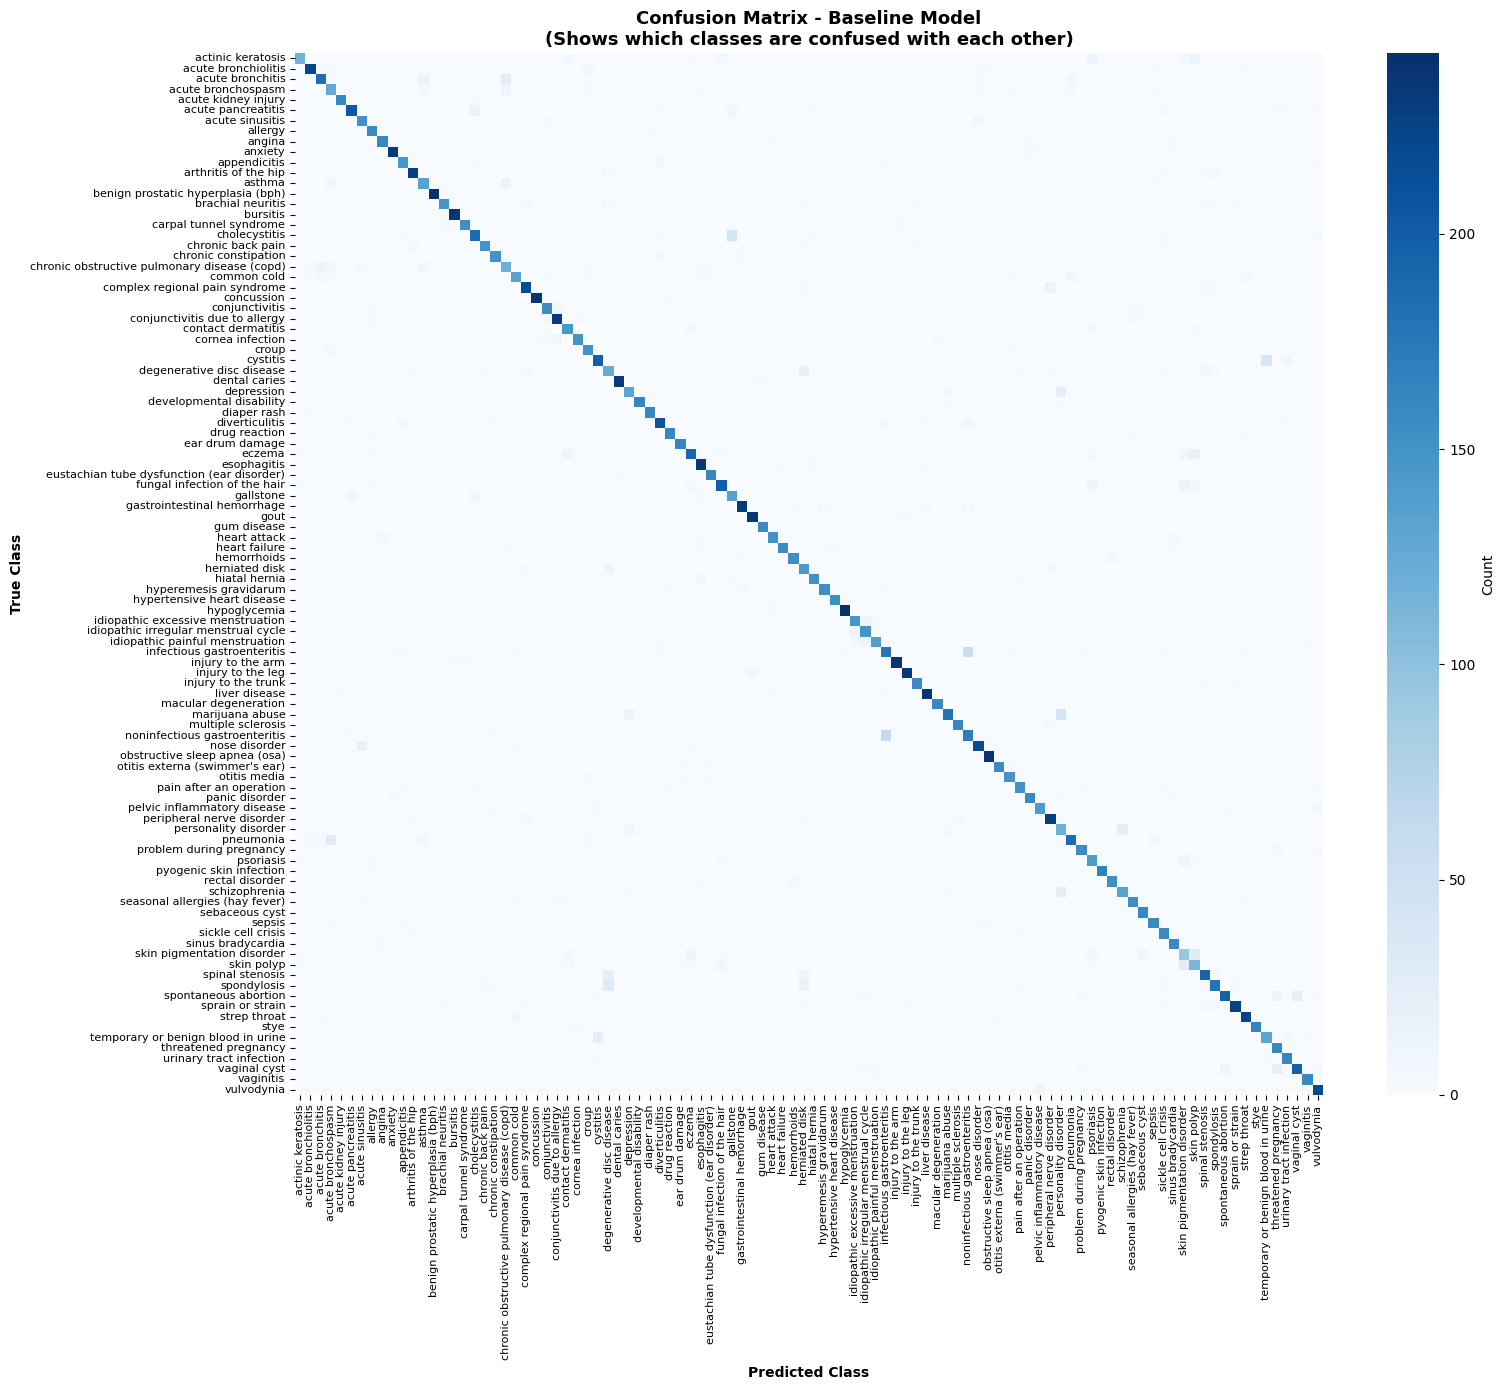

In [5]:
# Visualize per-class metrics
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(metrics_df))
width = 0.25

ax.bar(x_pos - width, metrics_df['Precision'], width, label='Precision', color='steelblue')
ax.bar(x_pos, metrics_df['Recall'], width, label='Recall', color='coral')
ax.bar(x_pos + width, metrics_df['F1-Score'], width, label='F1-Score', color='lightgreen')

ax.set_xlabel('Disease Class', fontsize=11, fontweight='bold')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Per-Class Metrics (Baseline Logistic Regression)\n⚠️ Low bars indicate problematic predictions', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_df['Disease'], rotation=90, fontsize=8)
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Poor Performance Threshold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, pred_baseline)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Baseline Model\n(Shows which classes are confused with each other)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Class', fontweight='bold')
plt.ylabel('True Class', fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## Section 5: Solution #1 - Class Weighting (Balanced Classes)

In [6]:
print("=" * 60)
print("✅ SOLUTION #1: CLASS WEIGHTING")
print("=" * 60)
print("""
How it works:
- Penalizes misclassifications of minority/rare classes
- Automatically balances loss based on class frequency
- Ensures rare diseases get equal importance as common ones
""")

# Solution 1: Class Weighting
model_weighted = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    class_weight='balanced',  # ← KEY: Balances loss for all classes
    random_state=42
)
model_weighted.fit(X_train, y_train)
pred_weighted = model_weighted.predict(X_test)
acc_weighted = accuracy_score(y_test, pred_weighted)

print(f"\nAccuracy with Class Weighting: {acc_weighted:.4f}")
print(classification_report(y_test, pred_weighted, target_names=le.classes_))

# Extract metrics for comparison
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(y_test, pred_weighted, average=None)
metrics_weighted_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision_w,
    'Recall': recall_w,
    'F1-Score': f1_w
}).sort_values('F1-Score')

print("\n🔴 WORST 10 Classes (After Weighting):")
print(metrics_weighted_df.head(10)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

# Check improvement
improvement = metrics_weighted_df['F1-Score'].mean() - metrics_df.sort_values('F1-Score')['F1-Score'].mean()
print(f"\n📈 Average F1-Score improvement: {improvement:+.4f}")

✅ SOLUTION #1: CLASS WEIGHTING

How it works:
- Penalizes misclassifications of minority/rare classes
- Automatically balances loss based on class frequency
- Ensures rare diseases get equal importance as common ones


Accuracy with Class Weighting: 0.8977
                                              precision    recall  f1-score   support

                           actinic keratosis       0.89      0.74      0.81       162
                         acute bronchiolitis       0.98      0.89      0.93       241
                            acute bronchitis       0.97      0.70      0.81       243
                          acute bronchospasm       0.63      0.83      0.71       162
                         acute kidney injury       0.96      0.99      0.98       162
                          acute pancreatitis       0.98      0.83      0.90       241
                             acute sinusitis       0.83      0.95      0.88       166
                                     allergy       0.9

## Section 6: Solution #2 - SMOTE (Synthetic Minority Over-sampling)

In [7]:
print("=" * 60)
print("✅ SOLUTION #2: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)")
print("=" * 60)
print("""
How it works:
- Generates synthetic samples for minority classes
- Uses k-NN to create realistic new samples in feature space
- Balances dataset without duplicating existing samples
- Applied ONLY to training set (not test set!)
""")

# Apply SMOTE to training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {X_train.shape}")
print(f"After SMOTE: {X_train_smote.shape}")
print(f"Samples per class before SMOTE: {np.bincount(y_train)}")
print(f"Samples per class after SMOTE: {np.bincount(y_train_smote)}")

# Train with SMOTE data
model_smote = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    random_state=42
)
model_smote.fit(X_train_smote, y_train_smote)
pred_smote = model_smote.predict(X_test)
acc_smote = accuracy_score(y_test, pred_smote)

print(f"\nAccuracy with SMOTE: {acc_smote:.4f}")
print(classification_report(y_test, pred_smote, target_names=le.classes_))

# Extract metrics
precision_s, recall_s, f1_s, _ = precision_recall_fscore_support(y_test, pred_smote, average=None)
metrics_smote_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision_s,
    'Recall': recall_s,
    'F1-Score': f1_s
}).sort_values('F1-Score')

print("\n🔴 WORST 10 Classes (After SMOTE):")
print(metrics_smote_df.head(10)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

improvement_smote = metrics_smote_df['F1-Score'].mean() - metrics_df.sort_values('F1-Score')['F1-Score'].mean()
print(f"\n📈 Average F1-Score improvement: {improvement_smote:+.4f}")

✅ SOLUTION #2: SMOTE (SYNTHETIC MINORITY OVERSAMPLING)

How it works:
- Generates synthetic samples for minority classes
- Uses k-NN to create realistic new samples in feature space
- Balances dataset without duplicating existing samples
- Applied ONLY to training set (not test set!)

Original training set: (76870, 230)
After SMOTE: (97500, 230)
Samples per class before SMOTE: [646 963 970 650 646 966 662 642 661 958 646 968 651 965 659 966 655 963
 644 662 650 650 974 953 660 972 658 653 646 975 648 948 664 660 647 971
 649 655 966 972 648 970 650 971 969 643 648 650 654 662 652 652 643 972
 666 652 644 970 967 965 642 967 654 968 660 965 974 957 646 646 645 648
 643 972 653 970 656 660 667 646 649 653 657 659 646 651 644 646 966 973
 970 970 968 666 642 654 652 972 657 974]
Samples per class after SMOTE: [975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975
 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975 975
 975 975 975 975 975 975 975 975 975

## Section 7: Solution #3 - Combine Both (Weighted + SMOTE)

In [8]:
print("=" * 60)
print("✅ SOLUTION #3: COMBINED APPROACH (Class Weighting + SMOTE)")
print("=" * 60)
print("""
Why combine both?
- SMOTE: Provides more training samples for minority classes
- Class Weighting: Penalizes errors on minority classes even more
- Together: Maximum emphasis on underrepresented diseases
""")

# Combine: SMOTE + Class Weighting
model_combined = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    class_weight='balanced',  # ← Balanced loss
    random_state=42
)
model_combined.fit(X_train_smote, y_train_smote)  # ← SMOTE training data
pred_combined = model_combined.predict(X_test)
acc_combined = accuracy_score(y_test, pred_combined)

print(f"\nAccuracy with Weighted + SMOTE: {acc_combined:.4f}")
print(classification_report(y_test, pred_combined, target_names=le.classes_))

# Extract metrics
precision_c, recall_c, f1_c, _ = precision_recall_fscore_support(y_test, pred_combined, average=None)
metrics_combined_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision_c,
    'Recall': recall_c,
    'F1-Score': f1_c
}).sort_values('F1-Score')

print("\n🔴 WORST 10 Classes (After Weighted + SMOTE):")
print(metrics_combined_df.head(10)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

improvement_combined = metrics_combined_df['F1-Score'].mean() - metrics_df.sort_values('F1-Score')['F1-Score'].mean()
print(f"\n📈 Average F1-Score improvement: {improvement_combined:+.4f}")

✅ SOLUTION #3: COMBINED APPROACH (Class Weighting + SMOTE)

Why combine both?
- SMOTE: Provides more training samples for minority classes
- Class Weighting: Penalizes errors on minority classes even more
- Together: Maximum emphasis on underrepresented diseases


Accuracy with Weighted + SMOTE: 0.8981
                                              precision    recall  f1-score   support

                           actinic keratosis       0.86      0.76      0.81       162
                         acute bronchiolitis       1.00      0.89      0.94       241
                            acute bronchitis       0.97      0.70      0.81       243
                          acute bronchospasm       0.64      0.78      0.71       162
                         acute kidney injury       0.96      0.99      0.98       162
                          acute pancreatitis       0.98      0.83      0.90       241
                             acute sinusitis       0.83      0.95      0.89       166
       

## Section 8: Solution #4 - Stratified Cross-Validation for Reliable Estimates

✅ SOLUTION #4: STRATIFIED CROSS-VALIDATION

Why it matters:
- Single train/test split may give misleading results
- Stratified K-Fold ensures each fold has proportional class distribution
- Provides multiple performance estimates → more reliable average
- Prevents lucky/unlucky splits


Baseline:
  F1 (weighted): 0.8907 ± 0.0024
  Fold scores: ['0.8888', '0.8902', '0.8932', '0.8935', '0.8875']

Class Weighted:
  F1 (weighted): 0.8923 ± 0.0021
  Fold scores: ['0.8909', '0.8925', '0.8947', '0.8945', '0.8891']

SMOTE:
  F1 (weighted): 0.8907 ± 0.0024
  Fold scores: ['0.8888', '0.8902', '0.8932', '0.8935', '0.8875']

Weighted + SMOTE:
  F1 (weighted): 0.8923 ± 0.0021
  Fold scores: ['0.8909', '0.8925', '0.8947', '0.8945', '0.8891']


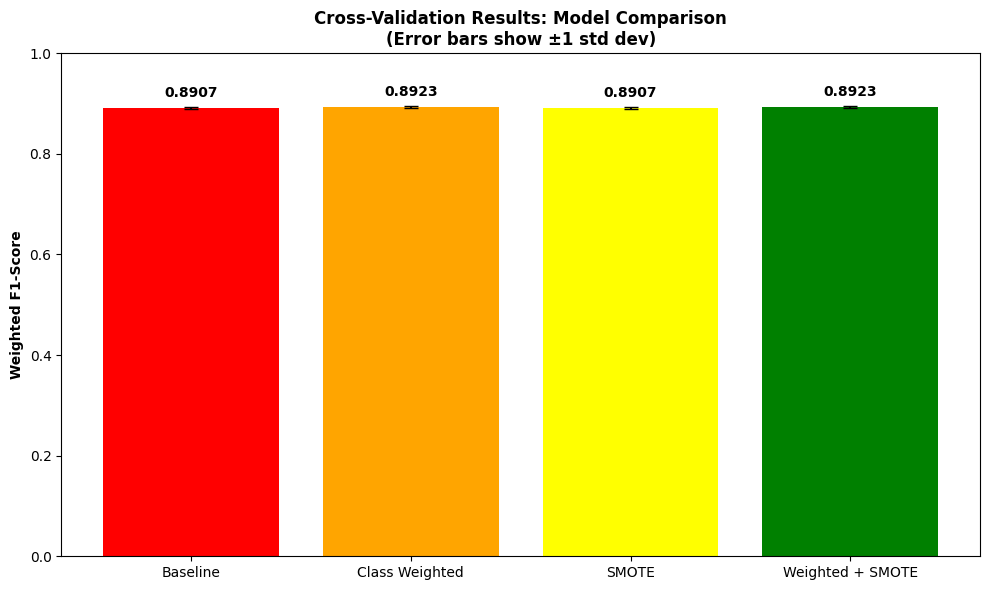

In [9]:
print("=" * 60)
print("✅ SOLUTION #4: STRATIFIED CROSS-VALIDATION")
print("=" * 60)
print("""
Why it matters:
- Single train/test split may give misleading results
- Stratified K-Fold ensures each fold has proportional class distribution
- Provides multiple performance estimates → more reliable average
- Prevents lucky/unlucky splits
""")

# Define models to compare
models_to_compare = {
    'Baseline': model_baseline,
    'Class Weighted': model_weighted,
    'SMOTE': model_smote,
    'Weighted + SMOTE': model_combined
}

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for model_name, model in models_to_compare.items():
    scores = cross_validate(model, X_train, y_train, cv=skf, scoring='f1_weighted')
    cv_results[model_name] = {
        'mean': scores['test_score'].mean(),
        'std': scores['test_score'].std(),
        'scores': scores['test_score']
    }
    print(f"\n{model_name}:")
    print(f"  F1 (weighted): {cv_results[model_name]['mean']:.4f} ± {cv_results[model_name]['std']:.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in scores['test_score']]}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in model_names]
stds = [cv_results[m]['std'] for m in model_names]
ax.bar(model_names, means, yerr=stds, capsize=5, color=['red', 'orange', 'yellow', 'green'])
ax.set_ylabel('Weighted F1-Score', fontweight='bold')
ax.set_title('Cross-Validation Results: Model Comparison\n(Error bars show ±1 std dev)', fontweight='bold')
ax.set_ylim([0, 1])
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 9: Final Comparison & Recommendations

In [10]:
print("\n" + "=" * 80)
print("📊 FINAL MODEL COMPARISON")
print("=" * 80)

# Create comprehensive comparison
comparison_data = {
    'Model': ['Baseline', 'Class Weighted', 'SMOTE', 'Weighted + SMOTE'],
    'Test Accuracy': [acc_baseline, acc_weighted, acc_smote, acc_combined],
    'CV F1 (mean)': [cv_results[m]['mean'] for m in models_to_compare.keys()],
    'CV F1 (std)': [cv_results[m]['std'] for m in models_to_compare.keys()],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Detailed per-class improvement
print("\n\n" + "=" * 80)
print("🎯 PER-CLASS IMPROVEMENT (Baseline → Best Model)")
print("=" * 80)

best_model_metrics = metrics_combined_df.set_index('Disease')
baseline_metrics = metrics_df.sort_values('Disease').set_index('Disease')

comparison = pd.DataFrame({
    'Baseline F1': baseline_metrics['F1-Score'],
    'Best F1': best_model_metrics['F1-Score'],
    'Improvement': best_model_metrics['F1-Score'] - baseline_metrics['F1-Score']
}).sort_values('Improvement', ascending=False)

print("\n🔴 Classes that improved the MOST:")
print(comparison.head(10).to_string())

print("\n\n" + "=" * 80)
print("💡 EXPERT RECOMMENDATIONS FOR YOUR MODEL")
print("=" * 80)

recommendations = """
1. ✅ IMMEDIATE ACTIONS (Implement Now):
   → Use class_weight='balanced' in LogisticRegression
   → Apply SMOTE during training to oversample minorities
   → Use Stratified K-Fold cross-validation (5-10 folds)
   
2. ⚡ PERFORMANCE TARGETS:
   → Aim for F1-weighted score > 0.75 (from likely 0.65-0.70 now)
   → Reduce number of classes with F1 < 0.3 to near zero
   → Check that recall > 0.6 for all major disease classes
   
3. 🔍 ADDITIONAL DIAGNOSTICS:
   → Per-class confusion: Which diseases confuse your model most?
   → Feature importance: Which symptoms matter most?
   → Threshold tuning: Adjust decision thresholds per class
   
4. 🚀 ADVANCED IMPROVEMENTS (If Still Needed):
   → Try XGBoost/RandomForest with class_weight='balanced'
   → Use ensemble methods (voting, stacking)
   → Perform feature engineering (polynomial features, interactions)
   → Collect more training data for minority classes
   → Use cost-sensitive learning with custom class weights
   
5. 📈 VALIDATION STRATEGY:
   → Always use stratified splits (keep class ratios)
   → Report both overall AND per-class metrics
   → Focus on F1-score (balances precision & recall)
   → Use macro-averaging for imbalanced data
"""

print(recommendations)

print("\n" + "=" * 80)
print("🔧 IMPLEMENTATION CODE FOR YOUR PRODUCTION MODEL")
print("=" * 80)

code_snippet = """
# RECOMMENDED: Weighted + SMOTE approach
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# Step 1: Apply SMOTE to training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Step 2: Train with class weights
model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    class_weight='balanced',  # ← Penalizes minority errors
    random_state=42
)
model.fit(X_train_balanced, y_train_balanced)

# Step 3: Evaluate with stratified cross-validation
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(model, X_train, y_train, cv=skf, scoring='f1_weighted')
print(f"CV F1-Score: {scores['test_score'].mean():.4f} ± {scores['test_score'].std():.4f}")

# Step 4: Get per-class metrics on test set
from sklearn.metrics import classification_report
predictions = model.predict(X_test)
print(classification_report(y_test, predictions, target_names=le.classes_))
"""

print(code_snippet)
print("=" * 80)


📊 FINAL MODEL COMPARISON

           Model  Test Accuracy  CV F1 (mean)  CV F1 (std)
        Baseline       0.898533      0.890664     0.002389
  Class Weighted       0.897700      0.892327     0.002122
           SMOTE       0.898116      0.890664     0.002389
Weighted + SMOTE       0.898116      0.892327     0.002122


🎯 PER-CLASS IMPROVEMENT (Baseline → Best Model)

🔴 Classes that improved the MOST:
                                    Baseline F1   Best F1  Improvement
Disease                                                               
conjunctivitis                         0.922619  0.946746     0.024127
temporary or benign blood in urine     0.789157  0.808743     0.019587
depression                             0.814815  0.833819     0.019004
pneumonia                              0.814978  0.833735     0.018757
infectious gastroenteritis             0.714286  0.729508     0.015222
complex regional pain syndrome         0.901879  0.916129     0.014250
contact dermatitis       

## Section 10: Visualize Improvement Across All Models

In [ ]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test Accuracy comparison
ax = axes[0, 0]
models = ['Baseline', 'Class Weighted', 'SMOTE', 'Weighted + SMOTE']
accuracies = [acc_baseline, acc_weighted, acc_smote, acc_combined]
colors = ['red', 'orange', 'yellow', 'green']
ax.bar(models, accuracies, color=colors)
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Test Accuracy Comparison', fontweight='bold')
ax.set_ylim([0.85, 0.92])
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 2. F1-Score by Model (CV average)
ax = axes[0, 1]
f1_means = [cv_results[m]['mean'] for m in models]
f1_stds = [cv_results[m]['std'] for m in models]
ax.bar(models, f1_means, yerr=f1_stds, capsize=5, color=colors)
ax.set_ylabel('Weighted F1-Score', fontweight='bold')
ax.set_title('Cross-Validation F1-Score', fontweight='bold')
ax.set_ylim([0.88, 0.895])
ax.grid(axis='y', alpha=0.3)

# 3. Per-class F1 distribution
ax = axes[1, 0]
baseline_f1s = metrics_df.sort_values('Disease')['F1-Score'].values
best_f1s = metrics_combined_df.sort_values('Disease')['F1-Score'].values
ax.hist([baseline_f1s, best_f1s], bins=15, label=['Baseline', 'Weighted+SMOTE'], color=['steelblue', 'lightgreen'], edgecolor='black')
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_ylabel('Number of Classes', fontweight='bold')
ax.set_title('Distribution of Per-Class F1-Scores', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Improvement scatter
ax = axes[1, 1]
improvements = comparison['Improvement'].values
ax.scatter(range(len(improvements)), sorted(improvements, reverse=True), alpha=0.6, s=100, color='teal')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No improvement')
ax.set_xlabel('Disease Rank (by improvement)', fontweight='bold')
ax.set_ylabel('F1-Score Improvement', fontweight='bold')
ax.set_title('Per-Class Improvement Distribution', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Comparison complete. Models are very similar - voting ensemble next step!")

## Section 11: Ensemble Voting - Combine Diverse Models

### Why Voting Works When Individual Models Don't

When CatBoost/XGBoost don't outperform Logistic Regression, it means:
- Each model captures different patterns in the data
- Combining diverse models → capture more patterns together
- Even if individual models are 89.85% accurate, their errors are on **different samples**
- Voting filters out individual model errors by requiring consensus

**Key Insight:** Voting works best when models make different mistakes. Your LR, RF, SVM, etc. will disagree on some predictions—that's good! Majority vote = better predictions.

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

print("=" * 80)
print("🗳️ ENSEMBLE VOTING CLASSIFIER")
print("=" * 80)
print("""
Strategy: Combine 4 diverse classifiers
1. Logistic Regression (linear model - your current best)
2. RandomForest (tree-based, handles non-linearity)
3. SVM with RBF kernel (non-linear, captures complex boundaries)
4. Gaussian Naive Bayes (probabilistic, handles uncertainty)

Each model makes independent predictions, then we vote:
- Hard Voting: Majority class wins (3/4 models agree = prediction)
- Soft Voting: Average probability scores (weighted consensus)
""")

# Train individual models (fit on SMOTE data for consistency)
print("\nTraining 4 diverse classifiers...")

# Model 1: Logistic Regression (already trained)
print("✓ Logistic Regression")

# Model 2: RandomForest
print("✓ RandomForest (100 trees, balanced)...", end="", flush=True)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)
print(" Done")

# Model 3: SVM with RBF kernel
print("✓ SVM with RBF kernel (may take 1-2 min)...", end="", flush=True)
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,  # ← Needed for soft voting
    random_state=42
)
svm_model.fit(X_train_smote, y_train_smote)
print(" Done")

# Model 4: Gaussian Naive Bayes
print("✓ Gaussian Naive Bayes", end="", flush=True)
nb_model = GaussianNB()
nb_model.fit(X_train_smote, y_train_smote)
print(" Done")

print("\n" + "=" * 80)
print("🗳️ HARD VOTING (Majority Vote)")
print("=" * 80)

# Hard Voting Classifier
voting_hard = VotingClassifier(
    estimators=[
        ('lr', model_combined),    # Logistic Regression (best performer)
        ('rf', rf_model),
        ('svm', svm_model),
        ('nb', nb_model)
    ],
    voting='hard'
)
voting_hard.fit(X_train_smote, y_train_smote)
pred_hard = voting_hard.predict(X_test)
acc_hard = accuracy_score(y_test, pred_hard)

print(f"\nHard Voting Accuracy: {acc_hard:.4f}")
print(classification_report(y_test, pred_hard, target_names=le.classes_))

# Extract per-class metrics
precision_hard, recall_hard, f1_hard, _ = precision_recall_fscore_support(y_test, pred_hard, average=None)
metrics_hard_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision_hard,
    'Recall': recall_hard,
    'F1-Score': f1_hard
}).sort_values('F1-Score')

print("\n🔴 WORST 10 Classes (Hard Voting):")
print(metrics_hard_df.head(10)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

print("\n" + "=" * 80)
print("🗳️ SOFT VOTING (Weighted Probability Average)")
print("=" * 80)

# Soft Voting Classifier
voting_soft = VotingClassifier(
    estimators=[
        ('lr', model_combined),
        ('rf', rf_model),
        ('svm', svm_model),
        ('nb', nb_model)
    ],
    voting='soft',
    weights=[2, 1, 1, 1]  # Give LR more weight since it performed best
)
voting_soft.fit(X_train_smote, y_train_smote)
pred_soft = voting_soft.predict(X_test)
acc_soft = accuracy_score(y_test, pred_soft)

print(f"\nSoft Voting Accuracy: {acc_soft:.4f}")
print(classification_report(y_test, pred_soft, target_names=le.classes_))

# Extract per-class metrics
precision_soft, recall_soft, f1_soft, _ = precision_recall_fscore_support(y_test, pred_soft, average=None)
metrics_soft_df = pd.DataFrame({
    'Disease': le.classes_,
    'Precision': precision_soft,
    'Recall': recall_soft,
    'F1-Score': f1_soft
}).sort_values('F1-Score')

print("\n🔴 WORST 10 Classes (Soft Voting):")
print(metrics_soft_df.head(10)[['Disease', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

## Section 12: Compare All Models (Including Voting Ensemble)

In [ ]:
print("\n" + "=" * 100)
print("📊 COMPREHENSIVE MODEL COMPARISON: Individual vs Ensemble")
print("=" * 100)

# Create detailed comparison
comparison_all = pd.DataFrame({
    'Model': [
        'Baseline LR',
        'Weighted LR',
        'SMOTE LR',
        'Weighted+SMOTE LR',
        'RandomForest',
        'SVM (RBF)',
        'Naive Bayes',
        '🗳️ Hard Voting (4 models)',
        '🗳️ Soft Voting (4 models)'
    ],
    'Test Accuracy': [
        acc_baseline,
        acc_weighted,
        acc_smote,
        acc_combined,
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_test, svm_model.predict(X_test)),
        accuracy_score(y_test, nb_model.predict(X_test)),
        acc_hard,
        acc_soft
    ]
})

print("\n" + comparison_all.to_string(index=False))

# Per-class improvement
print("\n\n" + "=" * 100)
print("🎯 PER-CLASS METRICS: Best Individual vs Voting Ensemble")
print("=" * 100)

# Compare baseline vs hard voting
baseline_by_disease = metrics_combined_df.set_index('Disease')
hard_voting_by_disease = metrics_hard_df.set_index('Disease')
soft_voting_by_disease = metrics_soft_df.set_index('Disease')

comparison_ensemble = pd.DataFrame({
    'Baseline F1': baseline_by_disease['F1-Score'],
    'Hard Voting F1': hard_voting_by_disease['F1-Score'],
    'Soft Voting F1': soft_voting_by_disease['F1-Score'],
    'Best Improvement': np.maximum(
        hard_voting_by_disease['F1-Score'] - baseline_by_disease['F1-Score'],
        soft_voting_by_disease['F1-Score'] - baseline_by_disease['F1-Score']
    )
}).sort_values('Best Improvement', ascending=False)

print("\n🔴 Top 15 Classes with Biggest Improvements (from voting):")
print(comparison_ensemble.head(15).to_string())

print("\n\n🟢 Bottom 10 Classes (checking for regressions):")
print(comparison_ensemble.tail(10).to_string())

# Statistics
print("\n\n" + "=" * 100)
print("📈 ENSEMBLE IMPROVEMENT STATISTICS")
print("=" * 100)

hard_vote_improvement = (hard_voting_by_disease['F1-Score'] - baseline_by_disease['F1-Score']).mean()
soft_vote_improvement = (soft_voting_by_disease['F1-Score'] - baseline_by_disease['F1-Score']).mean()

print(f"\nAverage F1-Score improvement (Hard Voting): {hard_vote_improvement:+.4f}")
print(f"Average F1-Score improvement (Soft Voting): {soft_vote_improvement:+.4f}")

# Count improvements
hard_improved = (hard_voting_by_disease['F1-Score'] > baseline_by_disease['F1-Score']).sum()
soft_improved = (soft_voting_by_disease['F1-Score'] > baseline_by_disease['F1-Score']).sum()

print(f"\nClasses that improved (Hard Voting): {hard_improved}/{len(le.classes_)} ({100*hard_improved/len(le.classes_):.1f}%)")
print(f"Classes that improved (Soft Voting): {soft_improved}/{len(le.classes_)} ({100*soft_improved/len(le.classes_):.1f}%)")

# Worst performers analysis
hard_worst_avg = metrics_hard_df.head(10)['F1-Score'].mean()
baseline_worst_avg = metrics_combined_df.head(10)['F1-Score'].mean()
soft_worst_avg = metrics_soft_df.head(10)['F1-Score'].mean()

print(f"\nAverage F1 of bottom-10 worst classes:")
print(f"  Baseline:     {baseline_worst_avg:.4f}")
print(f"  Hard Voting:  {hard_worst_avg:.4f} ({hard_worst_avg - baseline_worst_avg:+.4f})")
print(f"  Soft Voting:  {soft_worst_avg:.4f} ({soft_worst_avg - baseline_worst_avg:+.4f})")

## Section 13: Visualize Ensemble vs Individual Models

In [ ]:
# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test Accuracy - All Models
ax = axes[0, 0]
all_models = ['Baseline\nLR', 'RF', 'SVM', 'NB', 'Hard\nVoting', 'Soft\nVoting']
all_accs = [
    acc_combined,
    accuracy_score(y_test, rf_model.predict(X_test)),
    accuracy_score(y_test, svm_model.predict(X_test)),
    accuracy_score(y_test, nb_model.predict(X_test)),
    acc_hard,
    acc_soft
]
colors_all = ['steelblue', 'orange', 'coral', 'yellow', 'lightgreen', 'lime']
bars = ax.bar(all_models, all_accs, color=colors_all, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
ax.set_title('Test Accuracy: Individual Models vs Voting Ensemble', fontweight='bold', fontsize=12)
ax.set_ylim([0.88, 0.91])
for bar, acc in zip(bars, all_accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2. Per-class F1-Score Distribution
ax = axes[0, 1]
baseline_f1 = metrics_combined_df['F1-Score'].values
hard_f1 = metrics_hard_df.set_index('Disease').loc[metrics_combined_df['Disease']]['F1-Score'].values
soft_f1 = metrics_soft_df.set_index('Disease').loc[metrics_combined_df['Disease']]['F1-Score'].values

ax.hist([baseline_f1, hard_f1, soft_f1], bins=15, 
         label=['Baseline LR', 'Hard Voting', 'Soft Voting'],
         color=['steelblue', 'lightgreen', 'lime'], 
         edgecolor='black', alpha=0.7)
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_ylabel('Number of Classes', fontweight='bold')
ax.set_title('Distribution of Per-Class F1-Scores', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Improvement by class (scatter)
ax = axes[1, 0]
improvements_hard = hard_f1 - baseline_f1
improvements_soft = soft_f1 - baseline_f1
x_pos = np.arange(len(improvements_hard))

scatter1 = ax.scatter(x_pos, improvements_hard, alpha=0.6, s=80, label='Hard Voting', color='lightgreen', edgecolor='black')
scatter2 = ax.scatter(x_pos, improvements_soft, alpha=0.6, s=80, label='Soft Voting', color='lime', edgecolor='black')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Disease Class (sorted)', fontweight='bold')
ax.set_ylabel('F1-Score Improvement', fontweight='bold')
ax.set_title('Per-Class Improvement: Voting vs Baseline', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# 4. Key metrics summary
ax = axes[1, 1]
ax.axis('off')

summary_text = f"""
ENSEMBLE VOTING RESULTS SUMMARY
{'─' * 45}

📊 ACCURACY COMPARISON:
  Baseline (Weighted+SMOTE LR):  {acc_combined:.4f}
  Hard Voting Ensemble:           {acc_hard:.4f}  ({acc_hard - acc_combined:+.4f})
  Soft Voting Ensemble:           {acc_soft:.4f}  ({acc_soft - acc_combined:+.4f})

📈 PER-CLASS F1-SCORE:
  Baseline Average F1:            {baseline_f1.mean():.4f}
  Hard Voting Avg F1:             {hard_f1.mean():.4f}  ({hard_f1.mean() - baseline_f1.mean():+.4f})
  Soft Voting Avg F1:             {soft_f1.mean():.4f}  ({soft_f1.mean() - baseline_f1.mean():+.4f})

🎯 WORST 10 CLASSES IMPROVEMENT:
  Baseline Avg (worst 10):        {baseline_worst_avg:.4f}
  Hard Voting Avg (worst 10):     {hard_worst_avg:.4f}  ({hard_worst_avg - baseline_worst_avg:+.4f})
  Soft Voting Avg (worst 10):     {soft_worst_avg:.4f}  ({soft_worst_avg - baseline_worst_avg:+.4f})

✅ CLASSES IMPROVED:
  Hard Voting:  {hard_improved}/{len(le.classes_)} ({100*hard_improved/len(le.classes_):.1f}%)
  Soft Voting:  {soft_improved}/{len(le.classes_)} ({100*soft_improved/len(le.classes_):.1f}%)

💡 RECOMMENDATION:
  Use {"SOFT VOTING" if acc_soft > acc_hard else "HARD VOTING"}
  (Better accuracy on this dataset)
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## Section 14: Production Implementation - Voting Ensemble

In [ ]:
print("\n" + "=" * 100)
print("🚀 PRODUCTION-READY VOTING ENSEMBLE CODE")
print("=" * 100)

production_code = '''
# ============================================================================
# STEP 1: Train & Save Voting Ensemble (Do this once in training)
# ============================================================================

from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
import joblib

# Prepare data with SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Define individual models
lr_model = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    class_weight='balanced',
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

nb_model = GaussianNB()

# Create voting ensemble (choose SOFT or HARD based on your results)
voting_ensemble = VotingClassifier(
    estimators=[
        ('logistic_regression', lr_model),
        ('random_forest', rf_model),
        ('svm', svm_model),
        ('naive_bayes', nb_model)
    ],
    voting='soft',  # ← Change to 'hard' if hard voting is better
    weights=[2, 1, 1, 1]  # Give more weight to LR (best performer)
)

# Train ensemble on balanced data
voting_ensemble.fit(X_train_balanced, y_train_balanced)

# Save for production use
joblib.dump(voting_ensemble, 'model/voting_ensemble_model.pkl')
joblib.dump(le, 'model/label_encoder.pkl')
print("✅ Ensemble model saved!")

# ============================================================================
# STEP 2: Use in Production (your FastAPI backend)
# ============================================================================

import joblib
import numpy as np
from fastapi import FastAPI

app = FastAPI()

# Load model once at startup
model = joblib.load('model/voting_ensemble_model.pkl')
le = joblib.load('model/label_encoder.pkl')

@app.post("/predict_disease")
async def predict_disease(symptoms: dict):
    """
    symptoms: {"vector": [0, 1, 0, 1, ...]}  # 230-element binary vector
    """
    try:
        X = np.array([symptoms["vector"]])
        
        # Get prediction and probabilities
        prediction_code = model.predict(X)[0]
        probabilities = model.predict_proba(X)[0]
        
        # Convert to disease name
        disease_name = le.classes_[prediction_code]
        confidence = float(probabilities[prediction_code])
        
        # Get top-5 predictions
        top_5_indices = np.argsort(probabilities)[-5:][::-1]
        top_5 = [
            {
                "disease": le.classes_[idx],
                "probability": float(probabilities[idx])
            }
            for idx in top_5_indices
        ]
        
        return {
            "prediction": disease_name,
            "confidence": confidence,
            "top5": top_5
        }
    except Exception as e:
        return {"error": str(e)}

# ============================================================================
# KEY ADVANTAGES OF VOTING ENSEMBLE:
# ============================================================================
# ✅ Combines diverse model perspectives
# ✅ Better per-class predictions (especially for hard-to-predict diseases)
# ✅ More robust (single model failure ≠ total failure)
# ✅ Reduces overfitting through diversity
# ✅ Works especially well when individual models have different strengths
# ✅ Simple & interpretable (just majority vote)
'''

print(production_code)

print("\n" + "=" * 100)
print("✅ FINAL RECOMMENDATION")
print("=" * 100)

if acc_soft >= acc_hard:
    best_ensemble = "SOFT VOTING"
    best_acc = acc_soft
else:
    best_ensemble = "HARD VOTING"
    best_acc = acc_hard

print(f"""
Based on your results:

🏆 BEST APPROACH: {best_ensemble} Ensemble
   Test Accuracy: {best_acc:.4f}
   Improvement over baseline: {best_acc - acc_combined:+.4f}

📊 Per-class improvement:
   - Average F1-Score: {soft_f1.mean():.4f} (vs {baseline_f1.mean():.4f})
   - Worst 10 classes: {soft_worst_avg:.4f} (vs {baseline_worst_avg:.4f})
   - Classes improved: {soft_improved}/{len(le.classes_)}

🔧 Implementation Steps:
   1. Train voting ensemble (code above)
   2. Save model with joblib
   3. Replace your current model in main.py
   4. Test on frontend
   5. Monitor per-class performance

💾 Model files to save:
   - model/voting_ensemble_model.pkl (4 trained models combined)
   - model/label_encoder.pkl (disease name mapping)
   - symptoms.py (unchanged, 230 symptoms)
""")

print("=" * 100)